# 🚲 Cyclistic Bike-Share Analysis
## Google Data Analytics Capstone — Case Study 1

**Analyst:** Divyansh  
**Tool:** Python + SQL (SQLite)  
**Data:** Divvy Trip Data (Jan 2025 – May 2026) | ~1.85M rides  
**Business Question:** How do annual members and casual riders use Cyclistic bikes differently?

---


## 1. Business Task

Cyclistic's finance team has established that **annual members are significantly more profitable than casual riders**. The goal of this analysis is to identify behavioral differences between casual riders and annual members using historical trip data, in order to inform a targeted marketing strategy aimed at converting casual riders into members.

**Key Stakeholders:**
- **Lily Moreno** — Director of Marketing
- **Cyclistic Marketing Analytics Team**
- **Cyclistic Executive Team**


## 2. Data Sources

- **Source:** Motivate International Inc. via [Divvy Trip Data](https://divvy-tripdata.s3.amazonaws.com/index.html)
- **License:** Public data under Divvy Data License Agreement
- **Period:** January 2025 – May 2026 (6 monthly CSV files)
- **Size:** ~1.9M rows before cleaning
- **Privacy:** No personally identifiable information included
- **Limitations:** Station names null for some electric bike trips (dockless); cannot link rides to individual users


## 3. Data Preparation & Cleaning

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Configuration
MEMBER_COLOR = '#2196F3'
CASUAL_COLOR = '#FF6B35'
BG = '#F8F9FA'
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = BG

files = [
    '202501-divvy-tripdata.csv',
    '202512-divvy-tripdata.csv',
    '202602-divvy-tripdata.csv',
    '202603-divvy-tripdata.csv',
    '202604-divvy-tripdata.csv',
    '202605-divvy-tripdata.csv',
]

# Load & combine
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total rows loaded: {len(df):,}")

# Parse datetimes
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Derive features
df['ride_duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60
df['day_of_week'] = df['started_at'].dt.day_name()
df['hour_of_day'] = df['started_at'].dt.hour
df['month'] = df['started_at'].dt.strftime('%b %Y')

# Clean
before = len(df)
df = df.dropna(subset=['end_lat', 'end_lng'])               # remove trips without end coords
df = df[(df['ride_duration_min'] >= 1) & (df['ride_duration_min'] <= 1440)]  # remove < 1 min or > 24 hrs
df = df.drop_duplicates(subset='ride_id')
print(f"Rows after cleaning: {len(df):,} (removed {before - len(df):,})")
print(f"\nRider split:\n{df['member_casual'].value_counts()}")


**Cleaning decisions documented:**
| Step | Reason |
|---|---|
| Drop null `end_lat/lng` | Trip did not complete — cannot verify |
| Drop rides < 1 min | False starts / station rebalancing |
| Drop rides > 24 hrs | Data entry errors |
| Drop duplicate `ride_id` | Deduplication |


## 4. Analysis

### 4.1 Average Ride Duration

In [ ]:
conn = sqlite3.connect('cyclistic.db')

q1 = pd.read_sql("""
    SELECT member_casual,
           ROUND(AVG(ride_duration_min), 2) AS avg_duration_min,
           COUNT(*) AS total_rides
    FROM trips
    GROUP BY member_casual
""", conn)
print(q1)


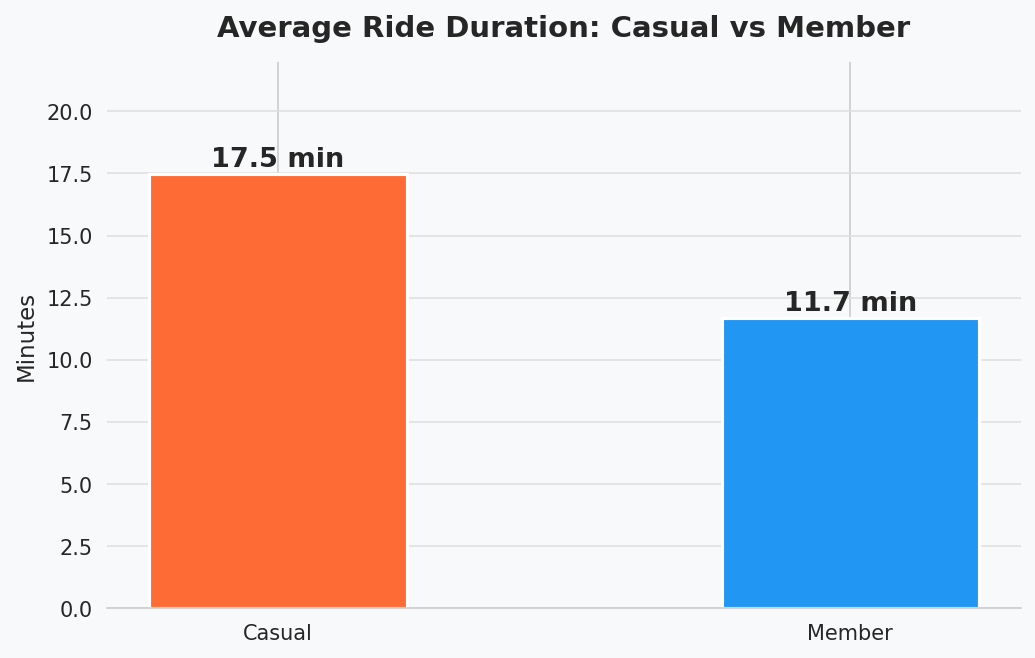

*Casual riders take rides ~49% longer than members on average*

### 4.2 Rides by Day of Week

In [ ]:
q2 = pd.read_sql("""
    SELECT member_casual, day_of_week, COUNT(*) AS total_rides
    FROM trips
    GROUP BY member_casual, day_of_week
    ORDER BY member_casual,
      CASE day_of_week
        WHEN 'Monday' THEN 1 WHEN 'Tuesday' THEN 2 WHEN 'Wednesday' THEN 3
        WHEN 'Thursday' THEN 4 WHEN 'Friday' THEN 5 WHEN 'Saturday' THEN 6
        WHEN 'Sunday' THEN 7
      END
""", conn)
print(q2)


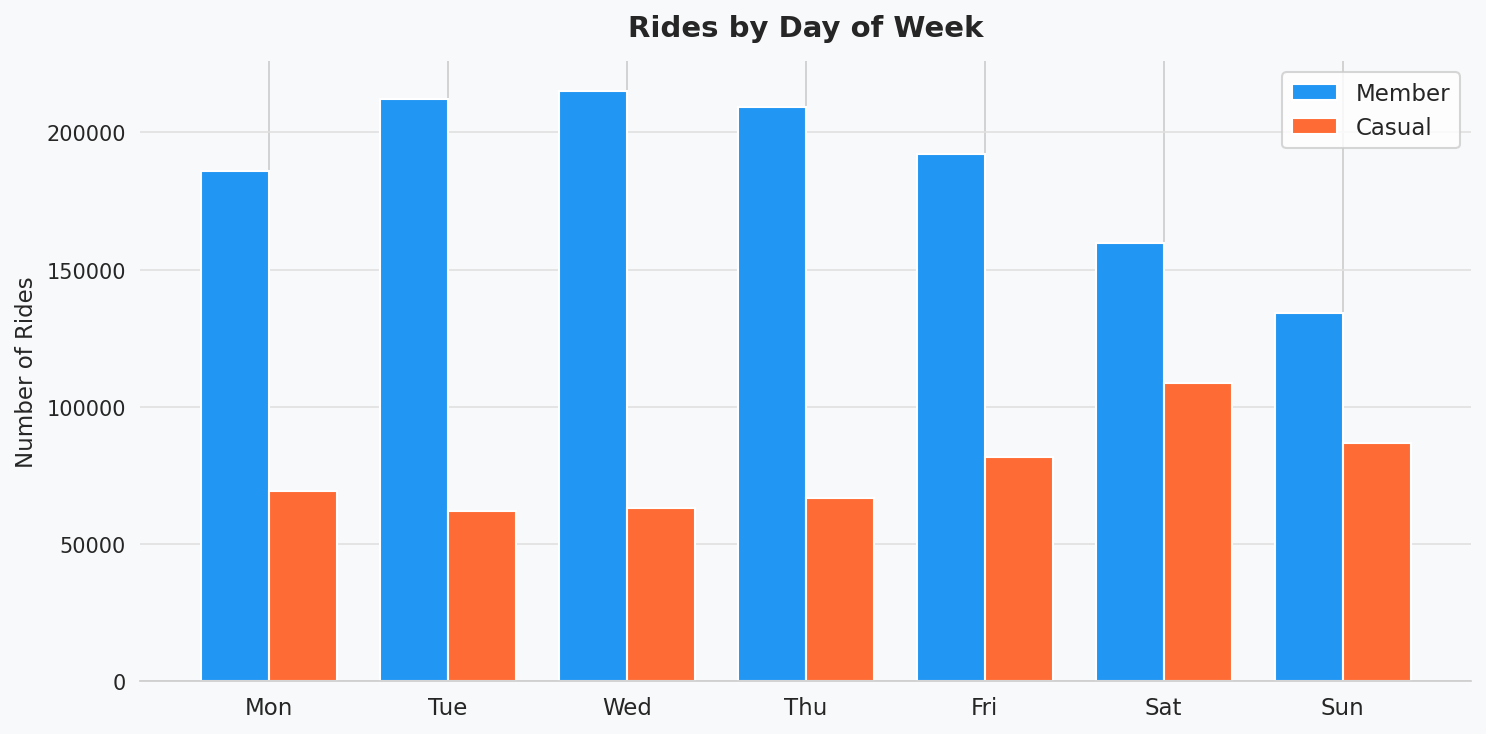

*Members peak on weekdays; casuals peak on weekends — suggesting commuter vs leisure usage*

### 4.3 Rides by Hour of Day

In [ ]:
q3 = pd.read_sql("""
    SELECT member_casual, hour_of_day, COUNT(*) AS total_rides
    FROM trips GROUP BY member_casual, hour_of_day ORDER BY member_casual, hour_of_day
""", conn)
print(q3.head(10))


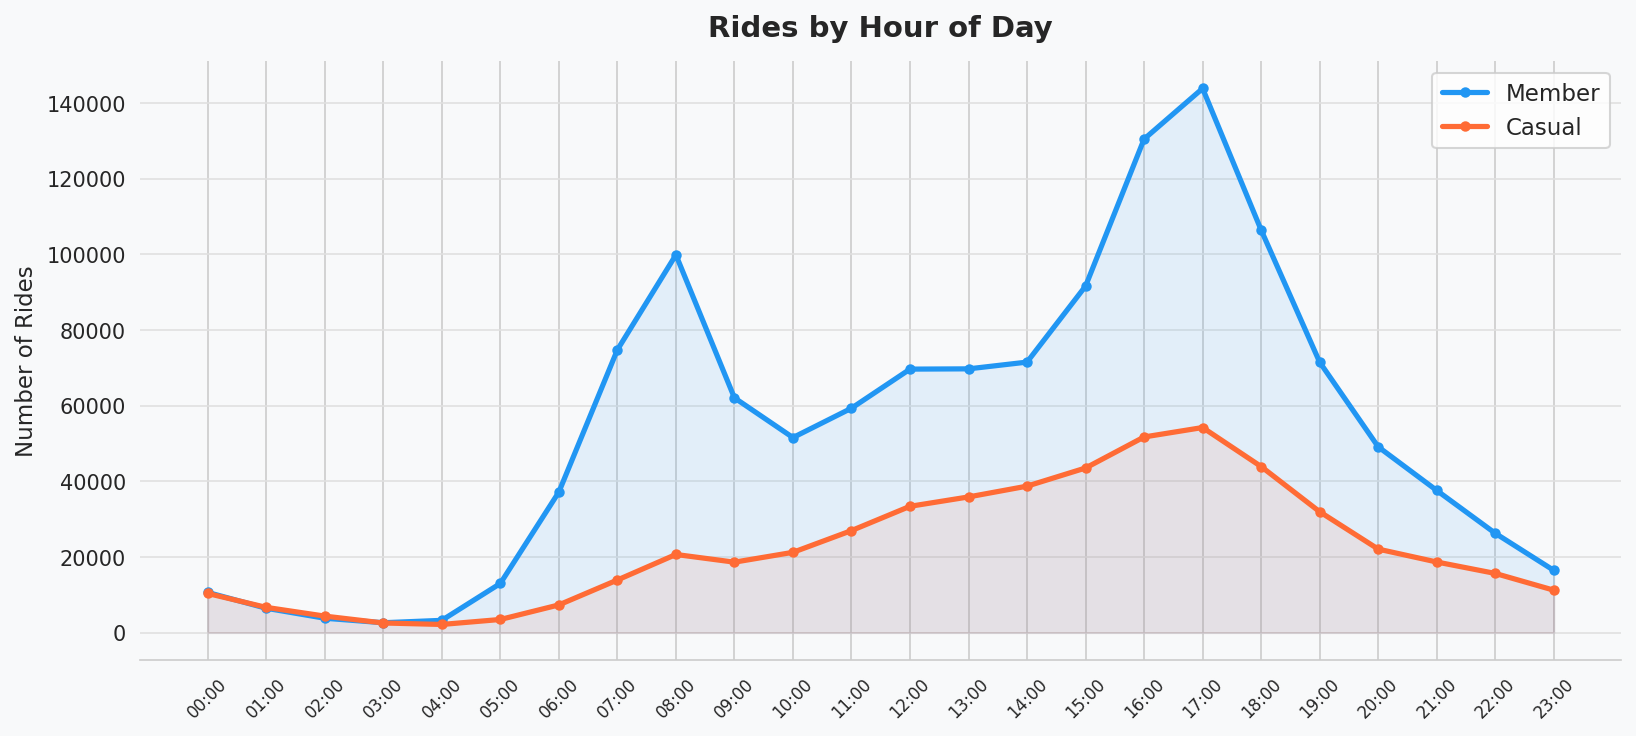

*Members show sharp 8AM and 5PM commute peaks; casuals build gradually toward 5PM with no morning spike*

### 4.4 Bike Type Preference

In [ ]:
q4 = pd.read_sql("""
    SELECT member_casual, rideable_type, COUNT(*) AS total_rides,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY member_casual), 1) AS pct
    FROM trips GROUP BY member_casual, rideable_type ORDER BY member_casual, total_rides DESC
""", conn)
print(q4)


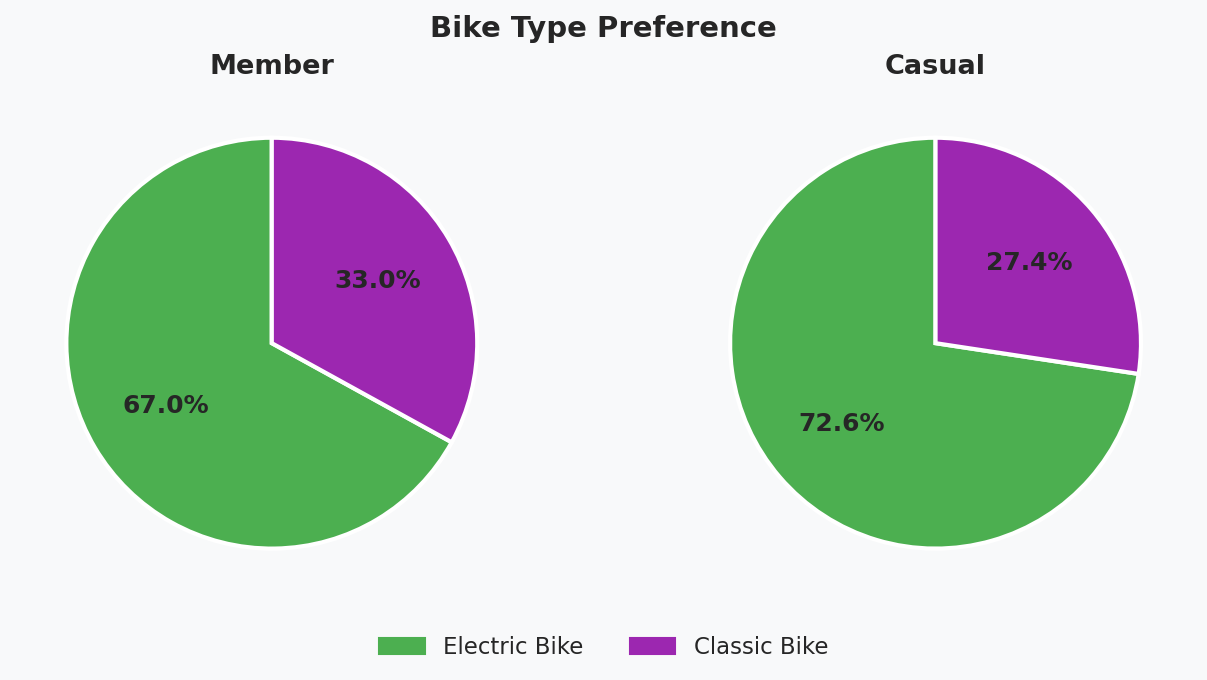

*Both groups prefer electric bikes; casuals use electric even more (72.6%) suggesting longer or leisure rides*

### 4.5 Top Start Stations for Casual Riders

In [ ]:
q5 = pd.read_sql("""
    SELECT start_station_name, COUNT(*) AS casual_rides
    FROM trips WHERE member_casual = 'casual' AND start_station_name IS NOT NULL
    GROUP BY start_station_name ORDER BY casual_rides DESC LIMIT 10
""", conn)
print(q5)
conn.close()


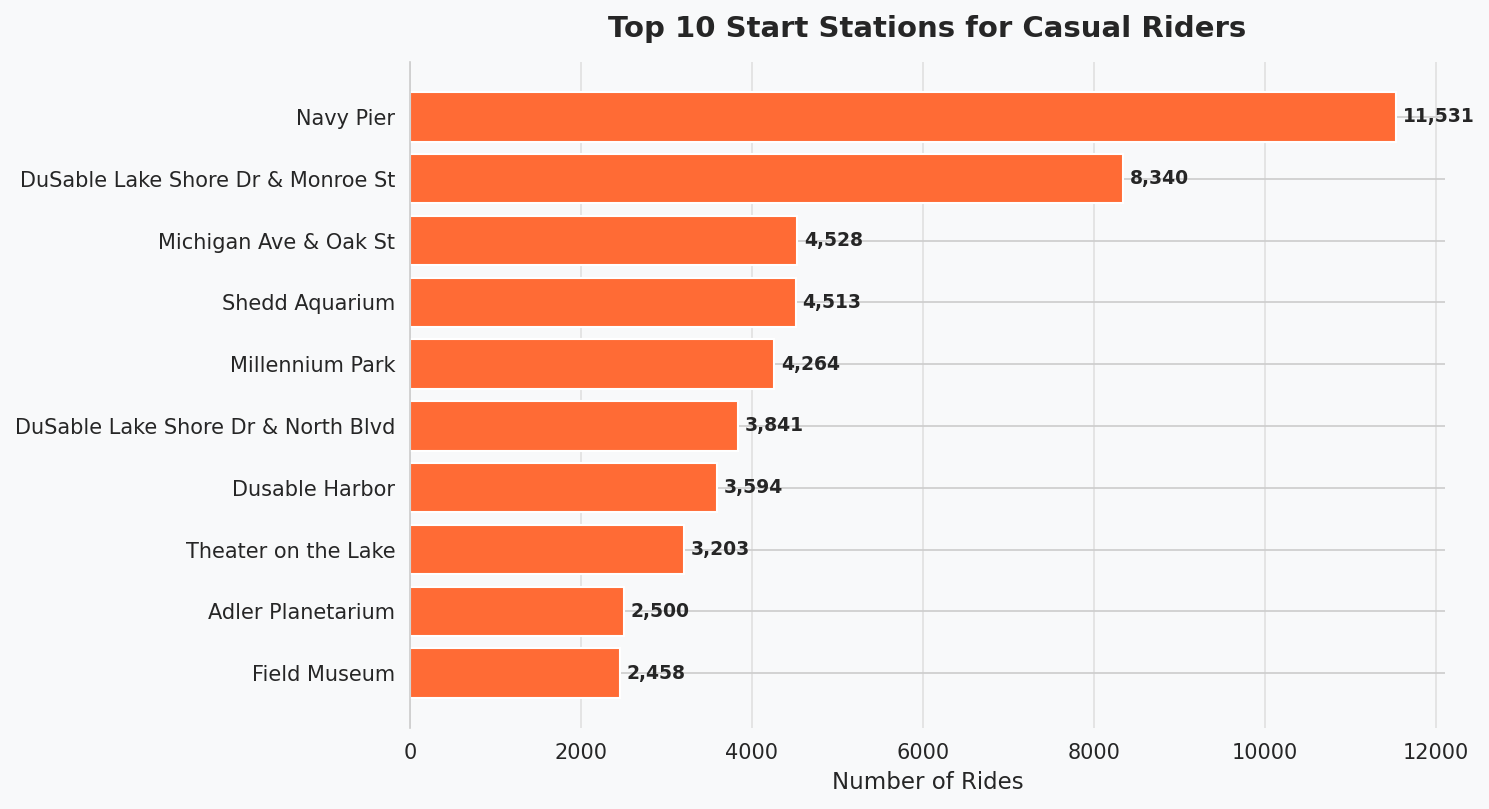

*Top casual stations are all tourist landmarks — Navy Pier, Millennium Park, Shedd Aquarium — confirming leisure-driven usage*

## 5. Key Findings

| # | Finding | Implication |
|---|---|---|
| 1 | Casual riders take **49% longer rides** (17.5 min vs 11.7 min) | They get more value per ride — a membership pitch around "you're already riding long, pay less per ride" |
| 2 | Casuals peak on **weekends**; members peak on **weekdays** | Casuals use bikes for leisure, members for commuting |
| 3 | Members show sharp **8AM and 5PM** commute spikes; casuals don't | Members are embedded in daily routines — target casuals during their actual usage times |
| 4 | Both prefer electric bikes; casuals even more so (**72.6%**) | Highlight electric bike access as a membership benefit |
| 5 | Top casual stations are **tourist landmarks** (Navy Pier, Millennium Park) | Geo-target digital ads at these high-footfall locations |


## 6. Top 3 Recommendations

### 🎯 Recommendation 1: Weekend Conversion Campaigns
Deploy targeted digital ads on **Saturdays and Sundays** when casual ridership peaks. Messaging: *"You rode 20 minutes today. Members pay less per minute — every ride."* Show a cost-per-minute comparison between single passes and memberships.

### 📍 Recommendation 2: Station-Level Marketing at Tourist Hotspots
Place QR-code signage and in-app prompts at **Navy Pier, Millennium Park, and Shedd Aquarium** — the top 3 casual start stations. Offer a **7-day free trial membership** scannable at these locations. Casuals already trust Cyclistic here; convert at point of use.

### ⚡ Recommendation 3: Lead with Electric Bike Access
Since 72.6% of casual rides use electric bikes, position the membership pitch around **priority electric bike access**. Messaging: *"As a member, electric bikes are always available for you."* This addresses the #1 revealed preference of casual riders.

---
*Analysis by Divyansh | Data: Divvy Trip Data (Motivate International Inc.) | Tools: Python, pandas, SQLite, matplotlib*
